In [10]:
#IMPORTS
import pandas as pd
import numpy as np
from skbio.stats.composition import clr
from scipy.stats import pearsonr
from typing import List, Tuple, Optional, Union
import seaborn as sns
import matplotlib.pyplot as plt

In [145]:
#FUNCTION DEFINITIONS

#A class for creating a population of sequences with a particular correlation to an input sequence of values
class SubPop():
    # Parameters- Each parameter will either create a single value (int) or a uniform range between two values (Tuple).
    # size: number of observations in the population.
    # slope: The range of correlations the population has with the dependent variable.
    # intercept: The intercept of the population count and the dependent variable.
    # variance: The variance of the population around the value determined by the.
    # zeros: The overall portion of null (0) values present in the data. Must be between 0 and 1.
    def __init(
        self,
        size: Union[int,Tuple[int,int]] = 0,
        slope: Union[int,Tuple[int,int]] = 1,
        intercept: Union[int,Tuple[int,int]] = 0,
        variance: Union[int,Tuple[int,int]] = 1,
        zeros: Union[int,Tuple[int,int]] = 0
    ):
        self._size = size,
        self._slope = slope,
        self._intercept = intercept,
        self._variance = variance

        assert zeros <= 1.0 and zeros >= 0
        self_zeros = zeros
    def _createRange(self, _range: Union[int, Tuple[int,int]]):
        if isinstance(_range,int):
            return _range
        else:
            return np.random.uniform(_range[0],_range[1])
    def size(self):
        return self._createRange(self._size)
    def slope(self):
        return self._createRange(self._slope)
    def intercept(self):
        return self._createRange(self._intercept)
    def variance(self):
        return self._createRange(self._variance)
    def zeros(self):
        return self._createRange(self._zeros)


def simulatePop(
    subPops: List[SubPop],
    input_vars: List[Union[int,float]],
    col_names: Optional[str] = None
):
    """
    Parameters:
    subPops: A List of subpopulations to comprise the whole population
    input_var: The sequence with which the simulated populations will be correlated
    col_names: The optional column names for the resulting data.
    
    Returns: A Pandas Dataframe containing all of the resulting observations, with column names matching the input variables.
    """
    sim_data = []
    for subPop in subPops:
        for i in range(subPop.size):
            dependent_vars = subPop.slope()*input_vars + subPop.intercept()
            dependent_vars += np.random.normal(0,subPop.variance()*dependent_vars.std(),len(dependent_vars))
            sim_data.append(dependent_var)
    if not col_names:
        try:
            pd.DataFrame(np.array(sim_data), columns = [str(var) for var in input_vars.tolist()])
        except:
            pd.DataFrame(np.array(sim_data), columns = [str(var) for var in range(len(input_vars))])
    return pd.DataFrame(np.array(sim_data), columns = col_names)


def calc_pearson(df, input_vars: List[Union[int,float]], drop_zeros = True):
    """
    Parameters:
    df[MxN]: dataframe containing various observations which are to be correlated to an input sequence
    input_var[1xN]: the input sequence
    drop_zeros: whether to drop all-zero rows from the dataframe when calculating r_value and p_value
    The input DataFrame must only include the columns for the observations which are correlated to the input sequence.

    Returns: A copy of df with columns r_value and p_values corresponding to significance and Pearson R correlation with input_var for each observation
    """
    assert df.shape[1] == len(input_vars)
    
    results=[]
    
    for idx, row in df.iterrows():
        vals = row.values
        r_value, p_value = pearsonr(input_vars, vals)
        results.append([r_value, p_value])
        
    corr_df = pd.DataFrame(results, columns=["r_value","p_value"],index=df.index)
    df1 = pd.concat((df,corr_df),axis=1)

    return df1

    
def percPositivePearson(df, alpha: float = .05):
    """
    Parameters:
    df: dataframe containing columns 'p_value' and 'r_value' corresponding to significance and Pearson R correlation
    alpha: P-value threshold to filter array by

    Returns: A float within [0,1] representing the portion of positive Pearson Correlations within the dataframe.
    """
    df_alpha = df[df['p_value'] <= alpha]
    pos_r = df_alpha[df_alpha['r_value'] > 0].shape[0]
    sig_r = df_alpha[df_alpha['r_value'] != 0].shape[0]
    return (pos_r/sig_r, sig_r)


def calc_ppp(df, input_vars: List[Union[int,float]], max_alpha: float = 1.0): 
    """
    Parameters:
    df[MxN]: dataframe containing various observations which are to be correlated to an input sequence
    input_var[1xN]: the input sequence
    max_alpha: the maximum alpha to look at.

    The input DataFrame must only include the columns for the observations which are correlated to the input sequence.

    Returns: A dataframe containing the % positive Pearson correlation between the observations in df and input_var,
    for each p-value in the range [0.0,1.0,0.01] 
    """
    if ('r_value' not in df.columns) or ('p_value' not in df.columns):
        # Calculating PearsonR for each row of df and adding that data to df in columns "r_value" and "p_value"
        df = calc_pearson(df,input_vars)
        
    # Calculating %PPC for each alpha value
    results = []
    for alpha in np.arange(max_alpha,0.0,-0.01):
        ppp, pop_size = percPositivePearson(df, alpha)
        results += [[alpha, ppp, pop_size]]
    
    # return %PPC and Pop-size df.
    return pd.DataFrame(results,columns=["alpha","ppp", "pop_size"])
    
def graph_ppp(
    df,
    input_vars: List[Union[int,float]],
    max_alpha: float = 1.0,
    name: str = "simulated population",
    processed: bool = False,
    include_pop_size: bool = True
):
    """
    Parameters:
    df[MxN]: dataframe containing various observations which are to be correlated to an input sequence
    input_var[1xN]: the input sequence
    max_alpha: the maximum alpha value to graph.
    name: the name of the population being sampled
    processed: Whether or not df has already been transformed into the correct form to be graphed
    include_pop_size: Whether or not to include a background area chart showing the % of overall sample population beating each p-value threshold

    The input DataFrame must only include the columns for the observations which are correlated to the input sequence.

    Displays: A chart showing % positive pearson correlation between the observations in the dataset and the input vars for only
    the observations beating each p-value threshold from 0 to 1.
    """
    if not processed:
        df = calc_ppp(df, input_vars, max_alpha = max_alpha)
    # Plotting %PPC vs. alpha for DF2 (0s dropped)
    fig, ax1 = plt.subplots(figsize=(8,6))
    ax1.scatter(df['alpha'],df['ppp'], s=20, alpha=0.6)
    ax1.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='50% threshold')
    ax1.set_ylim(0,1)
    ax1.set_xlabel("alpha")
    ax1.set_ylabel("% Positive Pearson Correlation")

    if include_pop_size:
        ax2 = ax1.twinx()
        ax2.fill_between(df['alpha'],0,df['pop_size'], alpha=0.2, color='gray', label='No. Observations beating threshold')
        ax2.set_ylabel('No. Observations beating threshold')
        ax2.tick_params(axis='y',labelcolor='gray')
    
    plt.title(f'% Positive Pearson Correlation vs. p-value Threshold ({name})')
    plt.tight_layout()
    plt.show()

In [20]:
#CONSTANTS
VOLTAGES = [0, 200, 400, 600, 800]

In [21]:
#INITIAL DATA UPLOAD
otu = pd.read_csv("MLEA_111724_otu_table.tsv",sep="\t")
print(df1.shape)
otu.head()

(999, 18)


,ASV_ID,10m_0_mV,10m_200_mV,10m_400_mV,10m_600_mV,10m_800_mV,10m_Cont,20_5m_0_mV,20_5m_200_mV,20_5m_400_mV,20_5m_600_mV,20_5m_800_mV,20_5m_Cont,35m_0_mV,35m_200_mV,35m_400_mV,35m_600_mV,35m_Cont
0,ASV1,66,99,32,64,34,25,72203,127654,159584,92823,72269,115132,202924,23469,147028,7471,135162
1,ASV2,0,0,0,0,0,0,46749,36924,53691,38346,38831,69707,171585,132630,250205,6513,18749
2,ASV3,66511,63841,47285,57228,41759,34774,31061,1619,1101,4657,2334,329,0,0,0,0,1700
3,ASV4,0,0,0,0,0,0,40556,37426,38838,45929,33071,50547,3543,10089,14496,583,4773
4,ASV5,0,0,0,0,0,0,30049,28073,50881,36177,41775,34733,8394,26975,18816,1608,2810


In [149]:
#INITIAL DATA UPLOAD
complete = pd.read_excel("MLEA_111724_otu_table_complete.xlsx", index_col=0)
dtype_mapping = {
    'numeric': float,
    'categorical': str
}
dtypes = dict(zip(complete.columns.tolist(), [dtype_mapping[dtype] for dtype in complete.iloc[0]]))
complete = pd.read_excel("MLEA_111724_otu_table_complete.xlsx", index_col=0, dtype=dtypes, skiprows=[1])
print(complete.shape)
complete.head()

(13791, 22)


,Taxon,Consensus,Sequence,Extraction_Blank,GL_111724_10m_0_V,GL_111724_10m_200_V,GL_111724_10m_400_V,GL_111724_10m_600_V,GL_111724_10m_800_V,GL_111724_10m_Cnt_V,...,GL_111724_20_5m_400_V,GL_111724_20_5m_600_V,GL_111724_20_5m_800_V,GL_111724_20_5m_Cnt_V,GL_111724_35m_0_V,GL_111724_35m_200_V,GL_111724_35m_400_V,GL_111724_35m_600_V,GL_111724_35m_Cnt_V,GL_111724_AncElec_V
id,,,,,,,,,,,,,,,,,,,,,
00009bf207093f9faba405063b3bd168,d__Bacteria; p__Proteobacteria; c__Alphaproteo...,1,TGGGGAATCTTGGACAATGGGGGCAACCCTGATCCAGCGATGCCGC...,0.0,0.0,0.0,0.0,0.0,0.0,20.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
00066c1bd7faac09db9ee4418f8c9133,d__Bacteria; p__Planctomycetota; c__Planctomyc...,0.6,TCGAGAATCTTCGGCAATGGGCGAAAGCCTGACCGAGCGACGCCGC...,0.0,81.0,22.0,31.0,26.0,0.0,103.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0006bcf50d74e3d3362657f3e7f98bb3,d__Bacteria; p__Verrucomicrobiota; c__Verrucom...,0.6,TCGAGAATTTTTCTCAATGGGGGAAACCCTGAAGGAGCGACGCCGC...,0.0,0.0,50.0,0.0,0.0,0.0,104.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0009e38c9cbd071a9403ea04c4e169b1,d__Bacteria; p__Bacteroidota; c__Bacteroidia; ...,1,TAAGGAATATTGGACAATGGTCGGAAGACTGATCCAGCCATGCCGC...,0.0,0.0,0.0,0.0,34.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0010c9ded97ac64f27db502a4a174415,d__Bacteria; p__Proteobacteria; c__Alphaproteo...,0.7,TGGGGAATATTGGACAATGGGGGCAACCCTGATCCAGCCATGCCGC...,0.0,0.0,10.0,0.0,0.0,12.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


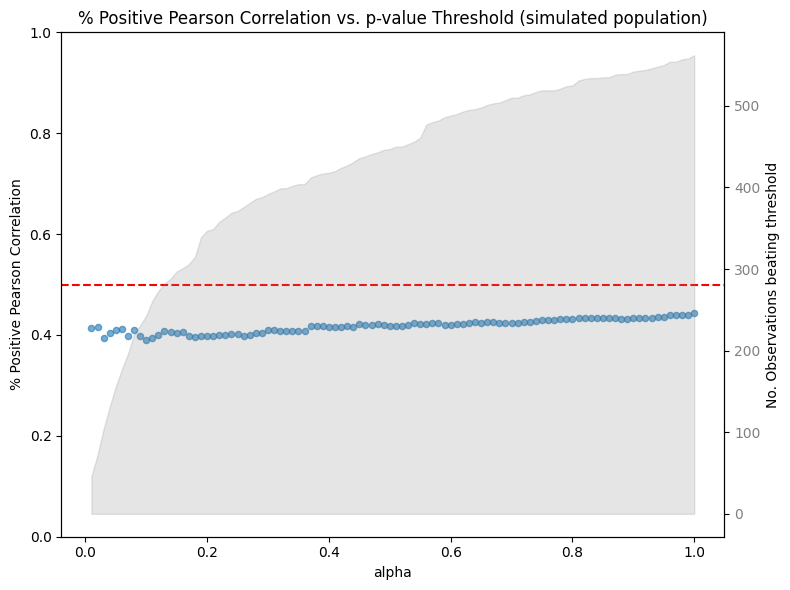

In [52]:
#Graph PPP for DF1, at 10m, 20.5m, 35m respectively.
otu_10m = otu.filter(regex=".*10m.*\\d.*")
otu_10m = otu_10m[otu_10m.any(axis=1)]
graph_ppp(otu_10m, VOLTAGES)

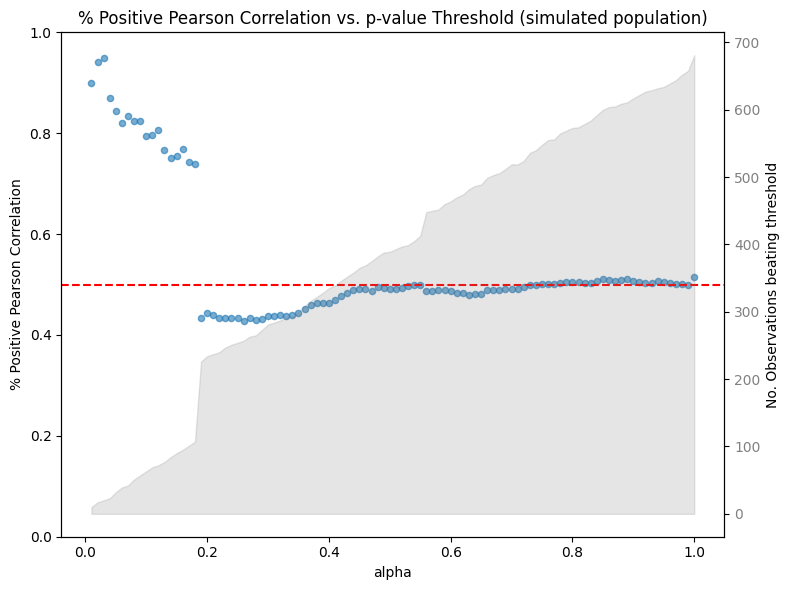

In [55]:
otu_20_5m = otu.filter(regex=".*20_5m.*\\d.*")
otu_20_5m = otu_20_5m[otu_20_5m.any(axis=1)]
graph_ppp(otu_20_5m, VOLTAGES)

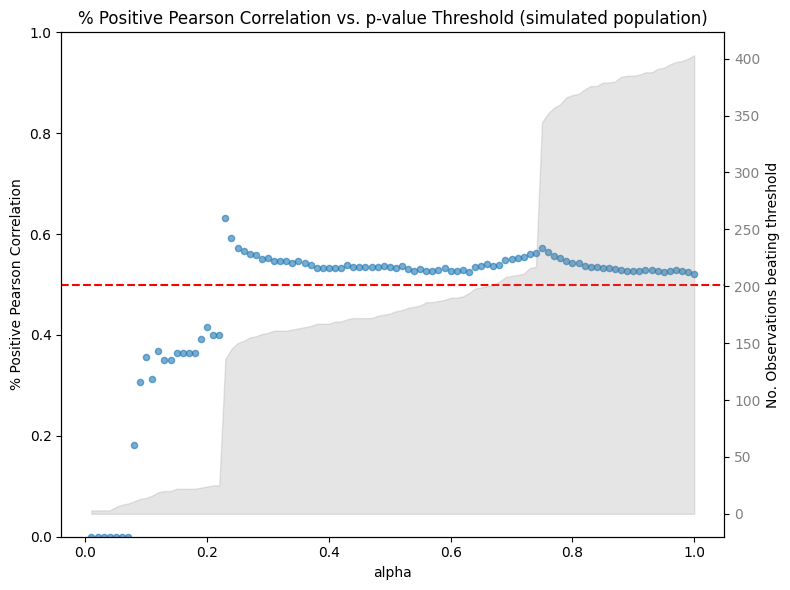

In [58]:
otu_35m = otu.filter(regex=".*35m.*\\d.*")
otu_35m = otu_35m[otu_35m.any(axis=1)]
graph_ppp(otu_35m, VOLTAGES[:4])

In [ ]:
#Now let's just graph the p and r values of each depth.
pearson_10m = calc_pearson(otu_10m, VOLTAGES)
pearson_20_5m = calc_pearson(otu_20_5m, VOLTAGES)
pearson_35m = calc_pearson(otu_35m, VOLTAGES[:4])

fig, ax = plt.subplots(figsize=(10,6))

ax.scatter(pearson_10m['r_value'], pearson_10m['p_value'], alpha=0.6, label = "otu 10m", s=50)
ax.scatter(pearson_20_5m['r_value'], pearson_20_5m['p_value'], alpha=0.6, label = "otu 20.5m", s=50)
ax.scatter(pearson_35m['r_value'], pearson_35m['p_value'], alpha=0.6, label = "otu 35m", s=50)

ax.set_xlabel('Pearson R-Correlation')
ax.legend()
ax.set_title('Pearson R-Correlations and p-values for {sequence counts vs electrode voltage}')

plt.tight_layout()
plt.show()

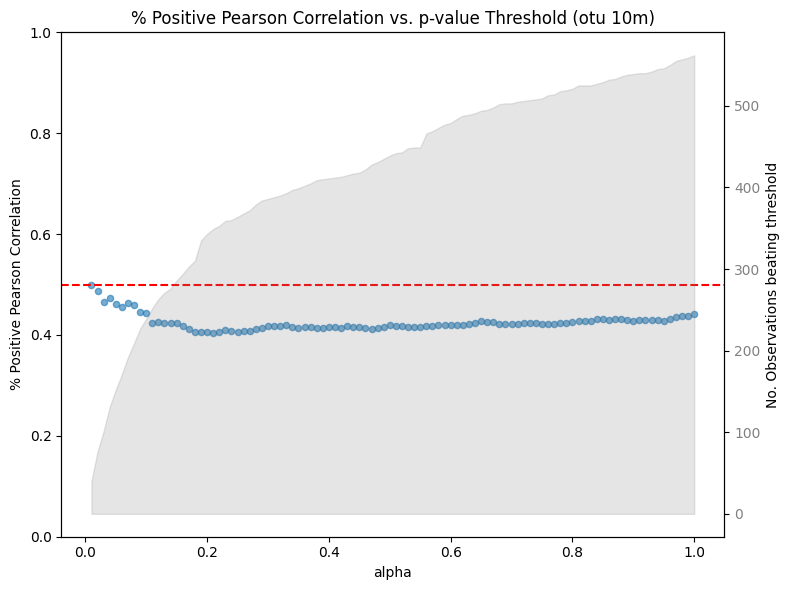

In [70]:
#Right, I now recall that P-value and Pearson R-correlation are highly correlated.They both came from the same damn function! Oops.
# Let's just move on. Now I'll graph the correlations on the CLR transformed data.
clr_10m = pd.DataFrame(clr(otu_10m+1), columns = [f'{col}_CLR' for col in otu_10m.columns])
graph_ppp(clr_10m, VOLTAGES, name="otu 10m")

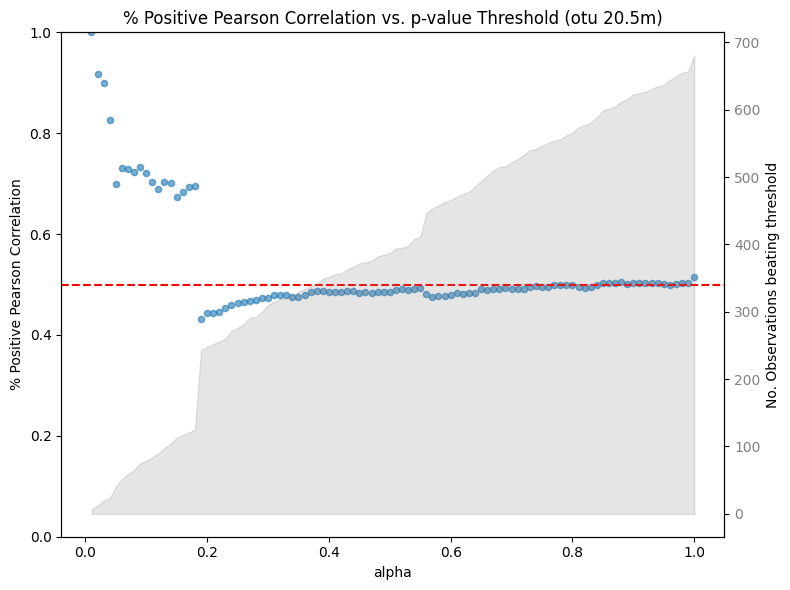

In [71]:
clr_20_5m = pd.DataFrame(clr(otu_20_5m+1), columns = [f'{col}_CLR' for col in otu_20_5m.columns])
graph_ppp(clr_20_5m, VOLTAGES, name="otu 20.5m")

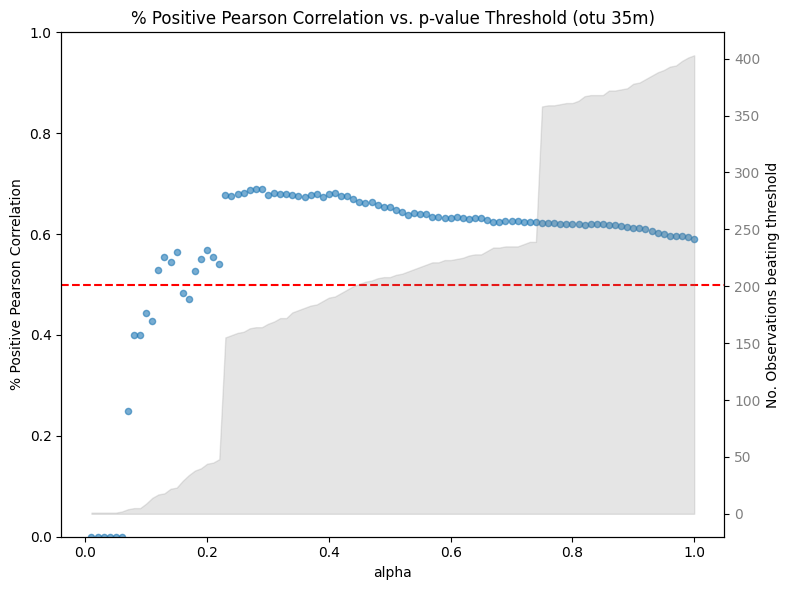

In [73]:
clr_35m = pd.DataFrame(clr(otu_35m+1), columns = [f'{col}_CLR' for col in otu_35m.columns])
graph_ppp(clr_35m, VOLTAGES[:4], name="otu 35m")

In [ ]:
#Now let's just graph the p and r values of each depth.
pearson_clr_10m = calc_pearson(clr_10m, VOLTAGES)
pearson_clr_20_5m = calc_pearson(clr_20_5m, VOLTAGES)
pearson_clr_35m = calc_pearson(clr_35m, VOLTAGES[:4])

fig, ax = plt.subplots(figsize=(10,6))

ax.scatter(pearson_clr_10m['r_value'], pearson_clr_10m['p_value'], alpha=0.6, label = "CLR otu 10m", s=50)
ax.scatter(pearson_clr_20_5m['r_value'], pearson_clr_20_5m['p_value'], alpha=0.6, label = "CLR otu 20.5m", s=50)
ax.scatter(pearson_clr_35m['r_value'], pearson_clr_35m['p_value'], alpha=0.6, label = "CLR out 35m", s=50)

ax.set_xlabel('Pearson R-Correlation')
ax.legend()
ax.set_title('Pearson R-Correlations and p-values for {sequence counts vs electrode voltage}')

plt.tight_layout()
plt.show()

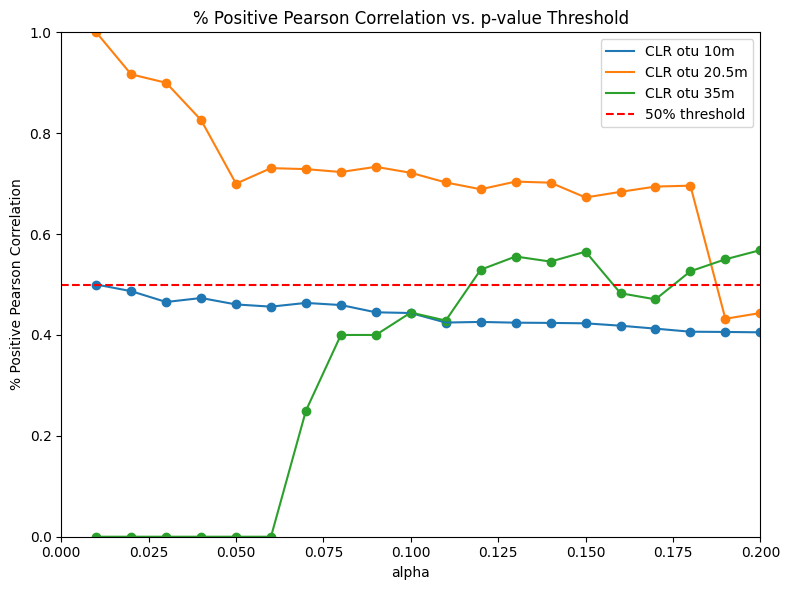

In [84]:
ppp0_2_10m = calc_ppp(clr_10m, VOLTAGES, max_alpha=0.2)
ppp0_2_20_5m = calc_ppp(clr_20_5m, VOLTAGES, max_alpha=0.2)
ppp0_2_35m = calc_ppp(clr_35m, VOLTAGES[:4], max_alpha=0.2)

fig, ax = plt.subplots(figsize=(8,6))

ax.plot(ppp0_2_10m['alpha'],ppp0_2_10m['ppp'],label="CLR otu 10m")
ax.plot(ppp0_2_20_5m['alpha'],ppp0_2_20_5m['ppp'],label="CLR otu 20.5m")
ax.plot(ppp0_2_35m['alpha'],ppp0_2_35m['ppp'],label="CLR otu 35m")
ax.scatter(ppp0_2_10m['alpha'],ppp0_2_10m['ppp'])
ax.scatter(ppp0_2_20_5m['alpha'],ppp0_2_20_5m['ppp'])
ax.scatter(ppp0_2_35m['alpha'],ppp0_2_35m['ppp'])
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='50% threshold')
ax.set_ylim(0,1)
ax.set_xlim(0,0.2)
ax.set_xlabel("alpha")
ax.set_ylabel("% Positive Pearson Correlation")

    
plt.title(f'% Positive Pearson Correlation vs. p-value Threshold')
plt.legend()
plt.tight_layout()
plt.show()

In [106]:
complete_10m = complete.filter(regex=".*10.*\\d.*V")
# complete_10m = complete_10m[~(complete_10m == 0).any(axis=1)]
print(complete_10m.shape)
complete_10m.head()

(13791, 5)


,GL_111724_10m_0_V,GL_111724_10m_200_V,GL_111724_10m_400_V,GL_111724_10m_600_V,GL_111724_10m_800_V
id,,,,,
00009bf207093f9faba405063b3bd168,0.0,0.0,0.0,0.0,0.0
00066c1bd7faac09db9ee4418f8c9133,81.0,22.0,31.0,26.0,0.0
0006bcf50d74e3d3362657f3e7f98bb3,0.0,50.0,0.0,0.0,0.0
0009e38c9cbd071a9403ea04c4e169b1,0.0,0.0,0.0,34.0,0.0
0010c9ded97ac64f27db502a4a174415,0.0,10.0,0.0,0.0,12.0


In [107]:
complete_20_5m = complete.filter(regex=".*20_5.*\\d.*V")
# complete_20_5m = complete_20_5m[~(complete_20_5m == 0).any(axis=1)]
print(complete_20_5m.shape)
complete_20_5m.head()

(13791, 5)


,GL_111724_20_5m_0_V,GL_111724_20_5m_200_V,GL_111724_20_5m_400_V,GL_111724_20_5m_600_V,GL_111724_20_5m_800_V
id,,,,,
00009bf207093f9faba405063b3bd168,0.0,0.0,0.0,0.0,0.0
00066c1bd7faac09db9ee4418f8c9133,0.0,0.0,0.0,0.0,0.0
0006bcf50d74e3d3362657f3e7f98bb3,0.0,0.0,0.0,0.0,0.0
0009e38c9cbd071a9403ea04c4e169b1,0.0,0.0,0.0,0.0,0.0
0010c9ded97ac64f27db502a4a174415,0.0,0.0,0.0,0.0,0.0


In [108]:
complete_35m = complete.filter(regex=".*35.*\\d.*V")
# complete_35m = complete_35m[~(complete_35m == 0).any(axis=1)]
print(complete_35m.shape)
complete_35m.head()

(13791, 4)


,GL_111724_35m_0_V,GL_111724_35m_200_V,GL_111724_35m_400_V,GL_111724_35m_600_V
id,,,,
00009bf207093f9faba405063b3bd168,0.0,0.0,0.0,0.0
00066c1bd7faac09db9ee4418f8c9133,0.0,0.0,0.0,0.0
0006bcf50d74e3d3362657f3e7f98bb3,0.0,0.0,0.0,0.0
0009e38c9cbd071a9403ea04c4e169b1,0.0,0.0,0.0,0.0
0010c9ded97ac64f27db502a4a174415,0.0,0.0,0.0,0.0


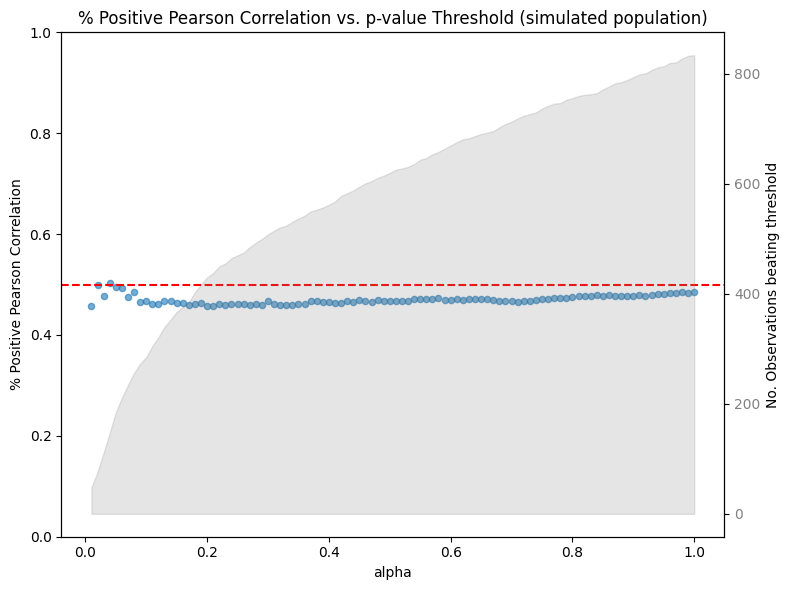

In [91]:
graph_ppp(complete_10m,VOLTAGES)

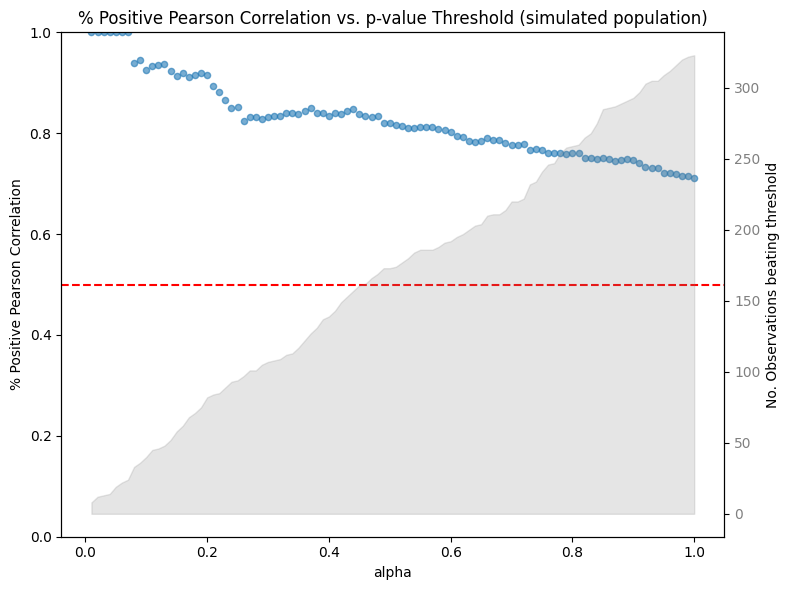

In [92]:
graph_ppp(complete_20_5m,VOLTAGES)

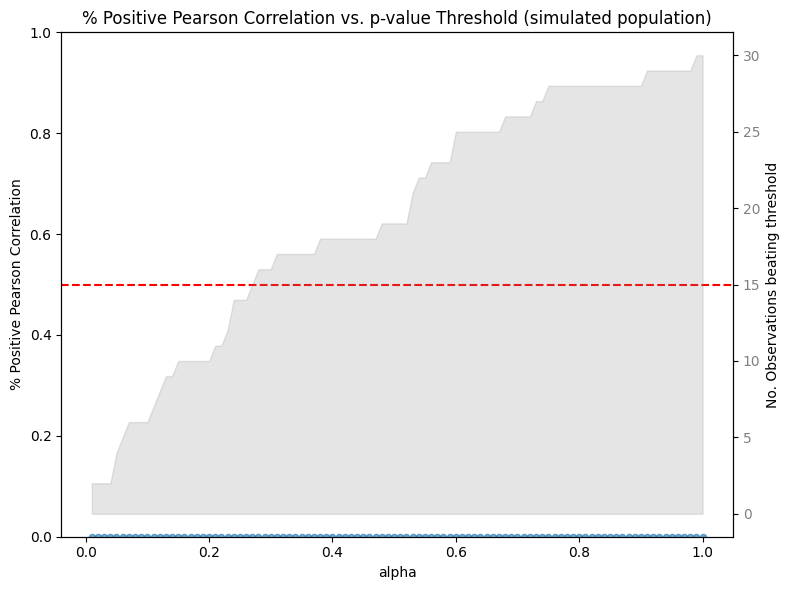

In [93]:
graph_ppp(complete_35m, VOLTAGES[:4])

In [ ]:
graph_ppp(pd.DataFrame(clr(complete_10m)),VOLTAGES)

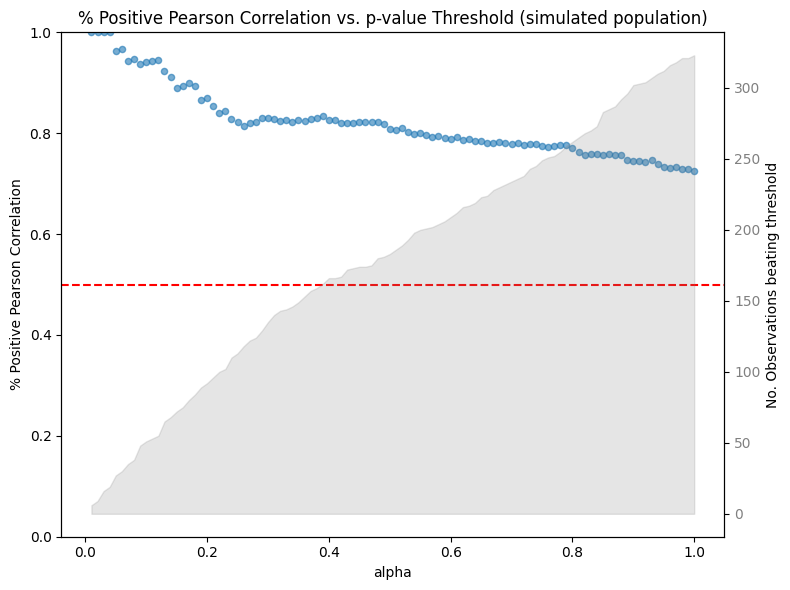

In [96]:
graph_ppp(pd.DataFrame(clr(complete_20_5m)),VOLTAGES)

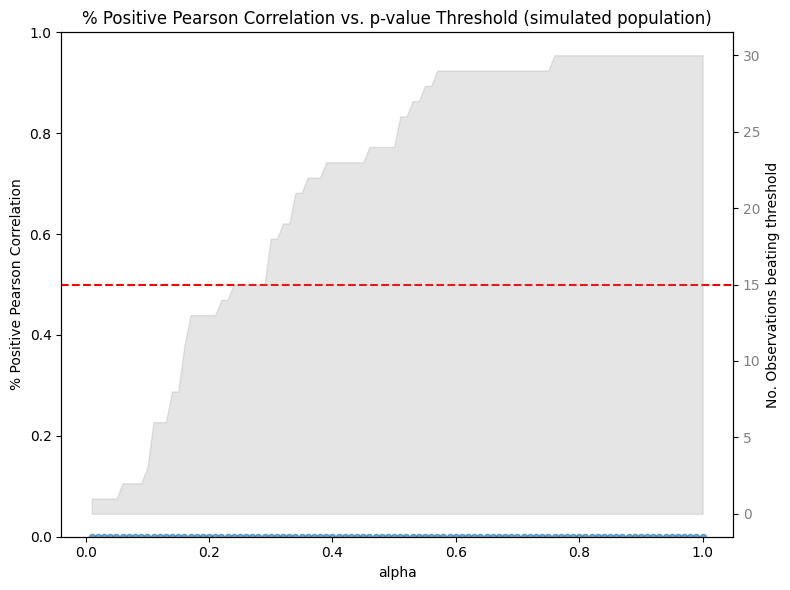

In [99]:
graph_ppp(pd.DataFrame(clr(complete_35m)),VOLTAGES[:4])

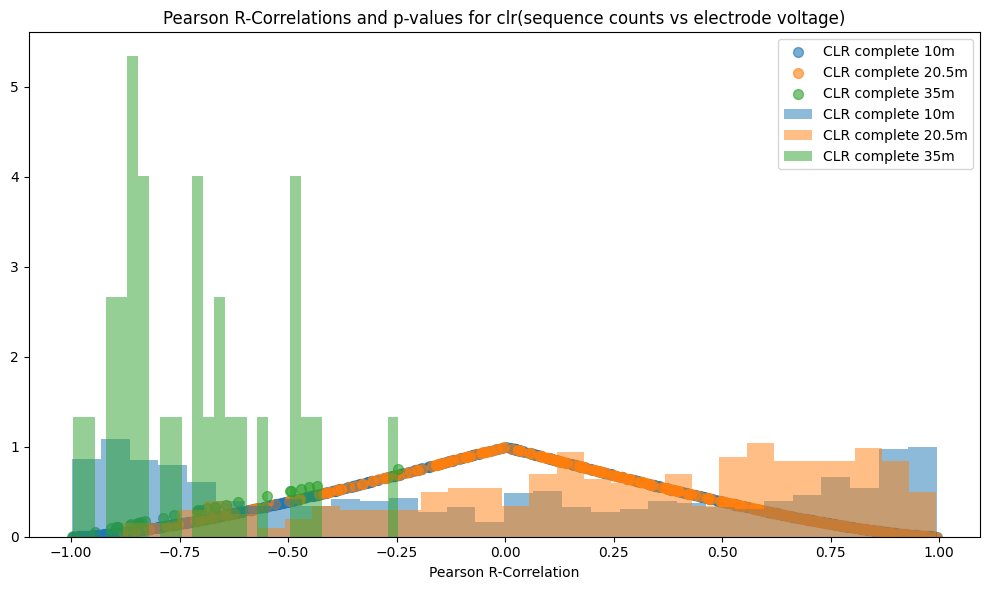

In [105]:
clr_10m_cpl = calc_pearson(pd.DataFrame(clr(complete_10m)), VOLTAGES)
clr_20_5m_cpl = calc_pearson(pd.DataFrame(clr(complete_20_5m)), VOLTAGES)
clr_35m_cpl = calc_pearson(pd.DataFrame(clr(complete_35m)), VOLTAGES[:4])
                           
fig, ax = plt.subplots(figsize=(10,6))

ax.scatter(clr_10m_cpl['r_value'], clr_10m_cpl['p_value'], alpha=0.6, label = "CLR complete 10m", s=50)
ax.scatter(clr_20_5m_cpl['r_value'], clr_20_5m_cpl['p_value'], alpha=0.6, label = "CLR complete 20.5m", s=50)
ax.scatter(clr_35m_cpl['r_value'], clr_35m_cpl['p_value'], alpha=0.6, label = "CLR complete 35m", s=50)

ax.hist(clr_10m_cpl['r_value'], bins=30, density=True, alpha=0.5, label = "CLR complete 10m")
ax.hist(clr_20_5m_cpl['r_value'], bins=30, density=True, alpha=0.5, label = "CLR complete 20.5m")
ax.hist(clr_35m_cpl['r_value'], bins=30, density=True, alpha=0.5, label = "CLR complete 35m")


ax.set_xlabel('Pearson R-Correlation')
ax.legend()
ax.set_title('Pearson R-Correlations and p-values for clr(sequence counts vs electrode voltage)')

plt.tight_layout()
plt.show()

C:\Users\EvanM\AppData\Local\Temp\ipykernel_6784\2365366611.py:86: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_value, p_value = pearsonr(input_vars, vals)
C:\Users\EvanM\AppData\Local\Temp\ipykernel_6784\2365366611.py:86: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_value, p_value = pearsonr(input_vars, vals)
C:\Users\EvanM\AppData\Local\Temp\ipykernel_6784\2365366611.py:86: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_value, p_value = pearsonr(input_vars, vals)


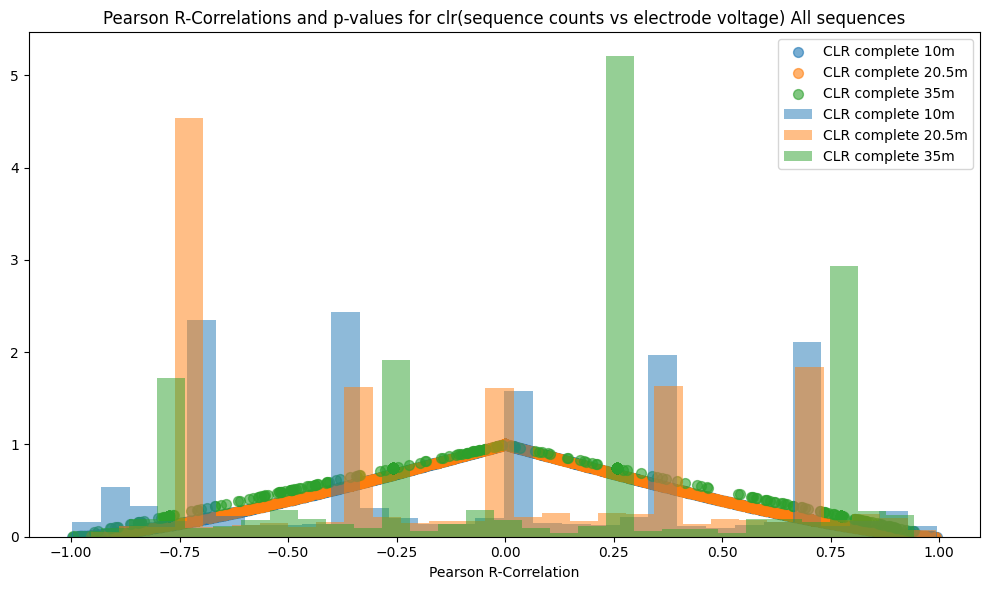

In [115]:
clr_10m_cpl = calc_pearson(pd.DataFrame(clr(complete_10m+1)), VOLTAGES)
clr_20_5m_cpl = calc_pearson(pd.DataFrame(clr(complete_20_5m+1)), VOLTAGES)
clr_35m_cpl = calc_pearson(pd.DataFrame(clr(complete_35m+1)), VOLTAGES[:4])
                           
fig, ax = plt.subplots(figsize=(10,6))

ax.scatter(clr_10m_cpl['r_value'], clr_10m_cpl['p_value'], alpha=0.6, label = "CLR complete 10m", s=50)
ax.scatter(clr_20_5m_cpl['r_value'], clr_20_5m_cpl['p_value'], alpha=0.6, label = "CLR complete 20.5m", s=50)
ax.scatter(clr_35m_cpl['r_value'], clr_35m_cpl['p_value'], alpha=0.6, label = "CLR complete 35m", s=50)

ax.hist(clr_10m_cpl['r_value'], bins=30, density=True, alpha=0.5, label = "CLR complete 10m")
ax.hist(clr_20_5m_cpl['r_value'], bins=30, density=True, alpha=0.5, label = "CLR complete 20.5m")
ax.hist(clr_35m_cpl['r_value'], bins=30, density=True, alpha=0.5, label = "CLR complete 35m")


ax.set_xlabel('Pearson R-Correlation')
ax.legend()
ax.set_title('Pearson R-Correlations and p-values for clr(sequence counts vs electrode voltage) All sequences')

plt.tight_layout()
plt.show()

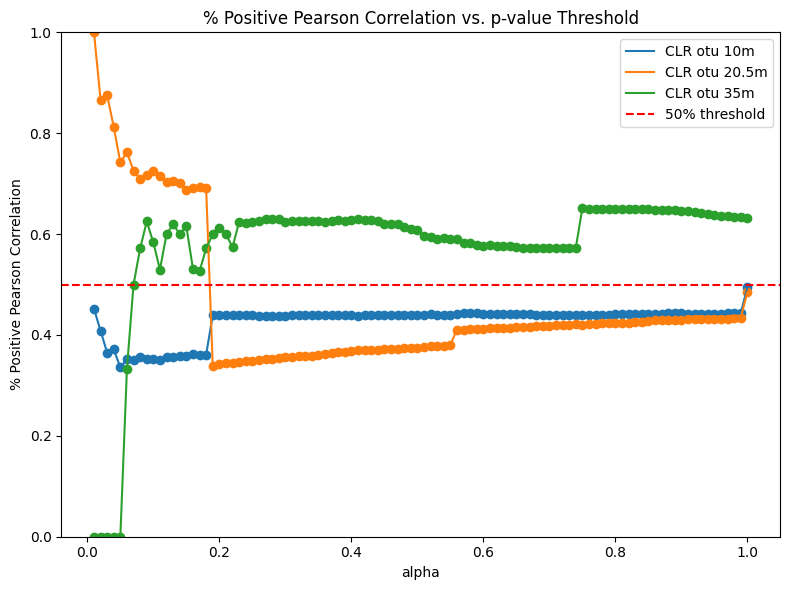

In [113]:
ppp0_2_10m = calc_ppp(clr_10m_cpl, VOLTAGES,)
ppp0_2_20_5m = calc_ppp(clr_20_5m_cpl, VOLTAGES)
ppp0_2_35m = calc_ppp(clr_35m_cpl, VOLTAGES[:4])


fig, ax = plt.subplots(figsize=(8,6))

ax.plot(ppp0_2_10m['alpha'],ppp0_2_10m['ppp'],label="CLR otu 10m")
ax.plot(ppp0_2_20_5m['alpha'],ppp0_2_20_5m['ppp'],label="CLR otu 20.5m")
ax.plot(ppp0_2_35m['alpha'],ppp0_2_35m['ppp'],label="CLR otu 35m")
ax.scatter(ppp0_2_10m['alpha'],ppp0_2_10m['ppp'])
ax.scatter(ppp0_2_20_5m['alpha'],ppp0_2_20_5m['ppp'])
ax.scatter(ppp0_2_35m['alpha'],ppp0_2_35m['ppp'])
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='50% threshold')
ax.set_ylim(0,1)
ax.set_xlabel("alpha")
ax.set_ylabel("% Positive Pearson Correlation")

    
plt.title(f'% Positive Pearson Correlation vs. p-value Threshold')
plt.legend()
plt.tight_layout()
plt.show()

In [146]:
clr_10m_cpl = calc_pearson(pd.DataFrame(clr(complete_10m+1)), VOLTAGES)
clr_10m_cpl.sort_values('p_value').head()

C:\Users\EvanM\AppData\Local\Temp\ipykernel_6784\3379593967.py:86: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_value, p_value = pearsonr(input_vars, vals)


,0,1,2,3,4,r_value,p_value
7311,0.941772,0.572025,-0.011560,-0.516116,-0.986120,-0.998195,0.000092
129,-0.812070,-0.499295,0.102252,0.394195,0.814918,0.994653,0.000469
2074,1.146952,0.606385,-0.031703,-0.724850,-0.996784,-0.992761,0.000738
2023,-1.192563,-0.491048,-0.126694,0.472445,1.337860,0.991406,0.000955
13257,0.669842,0.426220,-0.107862,-0.287834,-0.700366,-0.990903,0.001040


In [147]:
clr_cpl_10m = calc_pearson(pd.DataFrame(clr(complete_10m+1), index=complete.index), VOLTAGES)
clr_cpl_20_5m = calc_pearson(pd.DataFrame(clr(complete_20_5m+1), index=complete.index), VOLTAGES)
clr_cpl_35m = calc_pearson(pd.DataFrame(clr(complete_35m+1), index=complete.index), VOLTAGES[:4])

C:\Users\EvanM\AppData\Local\Temp\ipykernel_6784\3379593967.py:86: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_value, p_value = pearsonr(input_vars, vals)
C:\Users\EvanM\AppData\Local\Temp\ipykernel_6784\3379593967.py:86: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_value, p_value = pearsonr(input_vars, vals)
C:\Users\EvanM\AppData\Local\Temp\ipykernel_6784\3379593967.py:86: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_value, p_value = pearsonr(input_vars, vals)


In [148]:
clr_cpl_35m = pd.concat([clr_cpl_35m[["r_value","p_value"]],complete],axis=1, join='inner')
clr_cpl_35m.sort_values("p_value").head()

,r_value,p_value,Taxon,Consensus,Sequence,Extraction_Blank,GL_111724_10m_0_V,GL_111724_10m_200_V,GL_111724_10m_400_V,GL_111724_10m_600_V,...,GL_111724_20_5m_400_V,GL_111724_20_5m_600_V,GL_111724_20_5m_800_V,GL_111724_20_5m_Cnt_V,GL_111724_35m_0_V,GL_111724_35m_200_V,GL_111724_35m_400_V,GL_111724_35m_600_V,GL_111724_35m_Cnt_V,GL_111724_AncElec_V
id,,,,,,,,,,,,,,,,,,,,,
fbf02b9b65820ae14845f227ba480778,-0.994923,0.005077,d__Bacteria; p__Actinobacteriota; c__Actinobac...,1,TGGGGAATATTGCACAATGGGCGCAAGCCTGATGCAGCAACGCCGC...,0.0,521.0,397.0,358.0,624.0,...,253.0,129.0,151.0,144.0,3435.0,1586.0,434.0,132.0,1707.0,0.0
6cc3bca1eb4c489417d6ea681e3e0a0d,-0.945991,0.054009,d__Bacteria; p__Verrucomicrobiota; c__Omnitrop...,1,TCGAGGATATTTAGCAATGGGCGAAAGCCTGACTATGTGACGCCGC...,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3907.0,2576.0,909.0,93.0,0.0,124.0
57c3cdc14e0287e774ecdc2d297b4a91,0.943170,0.056830,d__Bacteria; p__Verrucomicrobiota; c__Omnitrop...,1,TCGAGGATATTTAGCAATGGGGGAAACCCTGACTATGTGACGCCGC...,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,21.0,75.0,0.0,14.0
5722f67d8436de83e5b0b9376388fd0e,0.939534,0.060466,d__Bacteria; p__Verrucomicrobiota; c__Omnitrop...,1,TCGAGGATATTTAGCAATGGGGGAAACCCTGACTATGTGACGCCGC...,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,28.0,89.0,141.0,0.0
e27ab218ba31b1a9c9ce3bd7df8d7bb2,-0.938342,0.061658,d__Bacteria; p__Firmicutes; c__Bacilli; o__Ize...,0.7,TAGGGAATTTTCGGCAATGGGGGGAACCCTGACCGAGCAATGCCGC...,0.0,0.0,0.0,0.0,0.0,...,840.0,447.0,385.0,280.0,13390.0,6880.0,346.0,0.0,575.0,1858.0


Index(['00009bf207093f9faba405063b3bd168', '00066c1bd7faac09db9ee4418f8c9133',
       '0006bcf50d74e3d3362657f3e7f98bb3', '0009e38c9cbd071a9403ea04c4e169b1',
       '0010c9ded97ac64f27db502a4a174415', '0014f2026df6b057ad4774e1845b31d3',
       '0018518cc5fcfdcfbfeb0a0d1b1af36d', '001935410b33e5c291c79b2b5ef43e6e',
       '001c15d71697f9121765d892a0c449a4', '001f5fea7f66d29f6efa8e35c9b1d51a',
       ...
       'ffd168ea37be974a74c8dfa3004cbdba', 'ffd8007c6595bca6206d1738e4fe6351',
       'ffdb6bcfb9df96b76b50b3734436cabc', 'ffdc45a6b37be38042af7b7b6bc7923e',
       'ffdc8e2dce6cbc86d9d6d02a8e962e8d', 'ffe060fd6257a5c488db4ea7a5834e47',
       'ffe1e63147af5c2cd21231f1d5d59488', 'ffe98dff68d760b39da140ff3810fa9d',
       'fffc4336f32f46f016b49ee35daf0ff0', 'fffe7f04472738f81a2b43934b373019'],
      dtype='object', name='id', length=13791)